Ranking the hosts of simulated BBH events.

The code was written by Mária Pálfi (marika97@student.elte.hu).

In [1]:
# importing useful packages and functions
import healpy as hp
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import norm
import pandas as pd
import json
from astropy import units as u
import astropy_healpix as ah
from ligo.skymap.io import read_sky_map
from scipy.interpolate import interp1d

/home/marika/.local/lib/python3.10/site-packages/ligo/lw/lsctables.py:89: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


Reading weights from Artale 

In [2]:
prob_M_BBH = pd.read_csv('../Probability_Mstar_BBH_z0p1.dat', delimiter='\t', 
                         header = 0, names = ['logMs', 'P'] )

Defining functions for ranking:

In [3]:
def find_nearest(array, value, return_array):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return return_array[idx]

def interpolate( x, lgM, prob, kind = 'linear' ):
    interpolator = interp1d( lgM, prob, kind=kind, fill_value='extrapolate')
    P = interpolator(x)
    P[x > prob_M_BBH.logMs[23]] = prob_M_BBH.P[23]
    return P

def dp_dV_calc(hosts, n, dp_dV, nside, ipix, prob, distmu, distsigma, distnorm, pixarea):
    match_ipix = ah.lonlat_to_healpix( hosts.iloc[n]['ra']*180/np.pi*u.deg, 
                                      hosts.iloc[n]['dec']*180/np.pi*u.deg,
                                      nside, order = 'nested'  )
    i = np.flatnonzero(ipix == match_ipix)[0]
    dp_dV.append( prob[i] * distnorm[i] * 
                     norm( distmu[i], distsigma[i] ).pdf(hosts.iloc[n]['dL']) 
                     / pixarea[i] )

    
def pM_Ducoin( hosts, M, dp_dV ):
    pM = M/np.sum(M)
    #print(np.sum(hosts[M>0]['dp_dV']))
    alpha = np.sum(hosts[M>0]['dp_dV'])/np.sum(hosts[M>0]['dp_dV']*pM[M>0])
    hosts['dp_dV_pM'] = dp_dV/np.sum(dp_dV)*(1+alpha*pM)
    return hosts.sort_values( by = ['dp_dV_pM'] , axis = 0, ascending = False ).index

def pM_Artale( hosts, M, dp_dV, mock = False ):
    prob_M_vals = []
    for i in range(len(M)):
        if M[i] > 0:
            if mock == True:
                lg_sm = np.log10(M[i]*0.73)+10
            else:
                lg_sm = np.log10(M[i])
            #print(M[i], lg_sm)
            prob_M_vals.append( find_nearest( prob_M_BBH['logMs'], lg_sm, prob_M_BBH['P'] ) )
        else:
            prob_M_vals.append( 0 )
    prob_M_Artale = prob_M_vals/np.sum(prob_M_vals)
    hosts['prob_M_Artale'] = prob_M_Artale
    alpha = np.sum(hosts[M>0]['dp_dV'])/np.sum(hosts[M>0]['dp_dV']*prob_M_Artale[M>0])
    hosts['prob_Artale'] = dp_dV/np.sum(dp_dV) * (1+alpha*hosts.prob_M_Artale)
    return hosts.sort_values( by = ['prob_Artale'] , axis = 0, ascending = False ).index

def pM_Artale_interpolate( hosts, M, dp_dV, mock = False ):
    prob_M_vals = []
    for i in range(len(M)):
        if M[i] > 0:
            if mock == True:
                lg_sm = np.log10(M[i]*0.73)+10
            else:
                lg_sm = np.log10(M[i])
            prob_M_vals.append( interpolate( lg_sm, prob_M_BBH['logMs'], prob_M_BBH['P'] ) )
        else:
            prob_M_vals.append( 0 )
    #print( 'prob: ', prob_M_vals )
    prob_M_Artale = prob_M_vals/np.sum(prob_M_vals)
    hosts['prob_M_Artale'] = prob_M_Artale
    alpha = np.sum(hosts[M>0]['dp_dV'])/np.sum(hosts[M>0]['dp_dV']*prob_M_Artale[M>0])
    hosts['prob_Artale'] = dp_dV/np.sum(dp_dV) * (1+alpha*hosts.prob_M_Artale)
    return hosts.sort_values( by = ['prob_Artale'] , axis = 0, ascending = False ).index


Defining functions for stellar mass estimation:

In [4]:
def abs_magni( m, dL ):
    return m - 5 * np.log10( dL ) - 25

def luminosity_W1( M1 ):
    return 10**( -0.4 * ( M1 - 3.24 ) ) #M_sun = 3.24

def M_Cluver( M1, M2, L_W1 ):
    TM = -1.96*( M1 - M2 ) - 0.03
    return L_W1 * 10**TM

def M_Jarrett( M1, M2, L_W1 ):
    TM = -0.246 - 2.1 *( M1 - M2 ) 
    return L_W1*10**(TM)

def M_Kettlety( L_W1 ):
    return 10**(-0.4)*L_W1

def M_Cappellari( M_K ):
    return 10**( 10.58 - 0.44 * (M_K + 23) ) 

Function for ranking the host of one event:

In [5]:
def sorting_one_event( num, just_one = False ):
    print( "Event ", num )
    if num in [133]:
        print( 'Skip event' + str(num) + '. Too small localization area!' )
    else:
        # Real host's coordinates
        f = open('../../to_zenodo/injections/injection' + str(num) + '.json')
        data = json.load(f)
        real_ra = data['injections']['content']['ra'][0]
        real_dec = data['injections']['content']['dec'][0]
        real_dL = data['injections']['content']['luminosity_distance'][0]
        f.close()
        
        # Read-in possible hosts
        hosts = pd.read_csv('../../to_zenodo/host_files/host' + str(num) + '.txt')
        if np.sum(  hosts['ra'] == real_ra ) == 0:
            print( 'Skip event' + str(num) + '. The real host is not in the 90% localization volume!' )
            not_in.append( num )

        elif np.sum(  hosts['dec'] == real_dec ) == 0:
            print( 'Skip event' + str(num) + '. The real host is not in the 90% localization volume!' )
            not_in.append( num )

        elif np.sum(  hosts['dL'] == real_dL ) == 0:
            print( 'Skip event' + str(num) + '. The real host is not in the 90% localization volume!' )
            not_in.append( num )

        else:
            # Where is the real host
            host_ra_idx = hosts.index[ hosts['ra'] == real_ra ][0]
            host_dec_idx = hosts.index[ hosts['dec'] == real_dec ][0]
            idx = hosts.index[ hosts['dL'] == real_dL ][0]
            if host_ra_idx == host_dec_idx & host_dec_idx == idx:
            
                hosts['M_B'] = abs_magni( hosts.m_B, hosts.dL )
                hosts['M_K'] = abs_magni( hosts.m_K, hosts.dL )
                hosts['M_W1'] = abs_magni( hosts.m_W1, hosts.dL )
                hosts['M_W2'] = abs_magni( hosts.m_W2, hosts.dL )
                # Calculating W1 band luminosity
                hosts['L_W1'] = luminosity_W1( hosts.M_W1 )
                # Calculating absolute magnitudes
                hosts['Jarrett'] = M_Jarrett( hosts.M_W1, hosts.M_W2, hosts.L_W1  )
                #print(hosts.Jarrett)
                hosts['Cluver'] = M_Cluver( hosts.M_W1, hosts.M_W2, hosts.L_W1  )
                hosts['Kettlety'] = M_Kettlety( hosts.L_W1 )
                hosts['Cappellari'] = M_Cappellari( hosts.M_K ) 

                #hosts.loc[np.log10(hosts.stellar_mass*0.73)+10 < 6, 'stellar_mass'] = 0
                mask = (hosts['Jarrett'] < 10**6) | (hosts['Cluver'] < 10**6) | (hosts['Kettlety'] < 10**6) | (hosts['Cappellari'] < 10**6)
                if mask.any():
                    print('Too low!')
                hosts.loc[hosts.Jarrett < 10**6, 'Jarrett'] = 0
                hosts.loc[hosts.Cluver < 10**6, 'Cluver'] = 0
                hosts.loc[hosts.Kettlety < 10**6, 'Kettlety'] = 0
                hosts.loc[hosts.Cappellari < 10**6, 'Cappellari'] = 0
                mask = (hosts['Jarrett'] > 10**13) | (hosts['Cluver'] > 10**13) | (hosts['Kettlety'] > 10**13) | (hosts['Cappellari'] > 10**13)
                if mask.any():
                    print('Too high!')
                #print(np.log10(max(hosts['Jarrett'])), np.log10(max(hosts['Cluver'])), np.log10(max(hosts['Kettlety'])), np.log10(max(hosts['Cappellari'])) ) 
                hosts.loc[hosts.Jarrett > 10**13, 'Jarrett'] = 0
                hosts.loc[hosts.Cluver > 10**13, 'Cluver'] = 0
                hosts.loc[hosts.Kettlety > 10**13, 'Kettlety'] = 0
                hosts.loc[hosts.Cappellari > 10**13, 'Cappellari'] = 0

                if num in [24, 30, 33, 44, 47, 80, 83, 84, 90, 96, 127, 129, 133, 135, 136, 141, 155, 159, 160, 169, 173]:
                    filename = "../../to_zenodo/skymap/skymaps/skymap"+str(num)+".fits"
                else:
                    filename = '../../to_zenodo/outdir_folder/bbh_injection_'+str(num)+'/result/bbh_injection_data0_0_analysis_H1L1V1_skymap.fits'
                skymap = read_sky_map( filename, moc = True )
                uniq = skymap['UNIQ']
                prob = skymap['PROBDENSITY']
                distnorm = skymap['DISTNORM']
                distmu = skymap['DISTMU']
                distsigma = skymap['DISTSIGMA']

                level, ipix = ah.uniq_to_level_ipix(uniq)
                nside = ah.level_to_nside(level)
                pixarea = hp.nside2pixarea(nside)

                dp_dV = []
                for n in range(len(hosts)): dp_dV_calc(hosts, n, dp_dV, nside, ipix,
                                                       prob, distmu, distsigma, distnorm, pixarea)
                hosts['dp_dV'] = dp_dV
                s_dp_dV = hosts.sort_values( by = ['dp_dV'] , axis = 0, ascending = False ).index
                s_dp_dV_list.append( np.argwhere( s_dp_dV == idx )[0][0] )
                
                s_Ducoin = pM_Ducoin( hosts, hosts.stellar_mass, dp_dV )
                s_Ducoin_list.append( np.argwhere( s_Ducoin == idx )[0][0] )
                s_Artale = pM_Artale( hosts, hosts.stellar_mass, dp_dV, mock = True )
                s_Artale_list.append( np.argwhere( s_Artale == idx )[0][0] )
                s_Artalei = pM_Artale_interpolate( hosts, hosts.stellar_mass, dp_dV, mock = True )
                s_Artalei_list.append( np.argwhere( s_Artalei == idx )[0][0] )
                
                s_D_Jarrett = pM_Ducoin( hosts, hosts.Jarrett, dp_dV )
                s_D_Jarrett_list.append( np.argwhere( s_D_Jarrett == idx )[0][0] )
                s_A_Jarrett = pM_Artale( hosts, hosts.Jarrett, dp_dV )
                s_A_Jarrett_list.append( np.argwhere( s_A_Jarrett == idx )[0][0] )
                s_Ai_Jarrett = pM_Artale_interpolate( hosts, hosts.Jarrett, dp_dV )
                s_Ai_Jarrett_list.append( np.argwhere( s_Ai_Jarrett == idx )[0][0] )
                                        
                s_D_Cluver = pM_Ducoin( hosts, hosts.Cluver, dp_dV )
                s_D_Cluver_list.append( np.argwhere( s_D_Cluver == idx )[0][0] )
                s_A_Cluver = pM_Artale( hosts, hosts.Cluver, dp_dV )
                s_A_Cluver_list.append( np.argwhere( s_A_Cluver == idx )[0][0] )
                s_Ai_Cluver = pM_Artale_interpolate( hosts, hosts.Cluver, dp_dV )
                s_Ai_Cluver_list.append( np.argwhere( s_Ai_Cluver == idx )[0][0] )

                s_D_Kettlety = pM_Ducoin( hosts, hosts.Kettlety, dp_dV )
                s_D_Kettlety_list.append( np.argwhere( s_D_Kettlety == idx )[0][0] )
                s_A_Kettlety = pM_Artale( hosts, hosts.Kettlety, dp_dV )
                s_A_Kettlety_list.append( np.argwhere( s_A_Kettlety == idx )[0][0] )
                s_Ai_Kettlety = pM_Artale_interpolate( hosts, hosts.Kettlety, dp_dV )
                s_Ai_Kettlety_list.append( np.argwhere( s_Ai_Kettlety == idx )[0][0] )

                s_D_Cappellari = pM_Ducoin( hosts, hosts.Cappellari, dp_dV )
                s_D_Cappellari_list.append( np.argwhere( s_D_Cappellari == idx )[0][0] )
                s_A_Cappellari = pM_Artale( hosts, hosts.Cappellari, dp_dV )
                s_A_Cappellari_list.append( np.argwhere( s_A_Cappellari == idx )[0][0] )
                s_Ai_Cappellari = pM_Artale_interpolate( hosts, hosts.Cappellari, dp_dV )
                s_Ai_Cappellari_list.append( np.argwhere( s_Ai_Cappellari == idx )[0][0] )
                
                length.append( len(hosts) )

                if just_one == True:
                    return s_dp_dV, s_Ducoin, s_Artale, s_Artalei, s_D_Jarrett, s_A_Jarrett, s_Ai_Jarrett, s_D_Cluver, s_A_Cluver, s_Ai_Cluver, s_D_Kettlety, s_A_Kettlety, s_Ai_Kettlety, s_D_Cappellari, s_A_Cappellari, s_Ai_Cappellari
            else:
                print( 'Skip event' + str(num) + '. The real host is not in the 90% localization volume!' )
                not_in.append( num )

In [6]:
# empty lists to save results
not_in, length = [], []
s_dp_dV_list, s_Ducoin_list, s_Artale_list, s_Artalei_list = [], [], [], []
s_D_Jarrett_list, s_D_Cluver_list, s_D_Kettlety_list, s_D_Cappellari_list = [], [], [], [] 
s_A_Jarrett_list, s_A_Cluver_list, s_A_Kettlety_list, s_A_Cappellari_list = [], [], [], [] 
s_Ai_Jarrett_list, s_Ai_Cluver_list, s_Ai_Kettlety_list, s_Ai_Cappellari_list = [], [], [], [] 

In [7]:
for e in range(195): sorting_one_event( e )

Event  0
Too low!
Event  1
Event  2
Event  3
Event  4
Event  5
Event  6
Too low!
Event  7
Event  8
Event  9
Event  10
Event  11
Event  12
Event  13
Skip event13. The real host is not in the 90% localization volume!
Event  14
Skip event14. The real host is not in the 90% localization volume!
Event  15
Skip event15. The real host is not in the 90% localization volume!
Event  16
Event  17
Event  18
Event  19
Too low!
Event  20
Event  21
Skip event21. The real host is not in the 90% localization volume!
Event  22
Event  23
Too low!
Event  24
Event  25
Too low!
Event  26
Event  27
Event  28
Skip event28. The real host is not in the 90% localization volume!
Event  29
Event  30
Event  31
Event  32
Event  33
Event  34
Skip event34. The real host is not in the 90% localization volume!
Event  35
Skip event35. The real host is not in the 90% localization volume!
Event  36
Too low!
Event  37
Event  38
Skip event38. The real host is not in the 90% localization volume!
Event  39
Skip event39. The re

In [8]:
len(s_dp_dV_list), len(not_in)

(147, 47)

Fraction when stellar mass is improving the ranking:

In [9]:
def fraction( listname ):
    filt = np.array(s_dp_dV_list) - np.array(listname) > 0 
    print( np.round(len(np.array(s_dp_dV_list)[filt])/len(np.array(s_dp_dV_list))*100) )

In [10]:
print( 'Ducoin with true value' )
fraction( s_Ducoin_list )
print( 'Artale with true value'  )
fraction( s_Artale_list )
print( 'Artale interpolated with true value'  )
fraction( s_Artalei_list )

print( 'Ducoin with Jarrett' )
fraction( s_D_Jarrett_list )
print( 'Artale with Jarrett' )
fraction( s_A_Jarrett_list )
print( 'Artale interpolated with Jarrett' )
fraction( s_Ai_Jarrett_list )

print( 'Ducoin with Cluver' )
fraction( s_D_Cluver_list )
print( 'Artale with Cluver' )
fraction( s_A_Cluver_list )
print( 'Artale interpolated with Cluver' )
fraction( s_Ai_Cluver_list )

print( 'Ducoin with Kettlety' )
fraction( s_D_Kettlety_list,  )
print( 'Artale with Kettlety' )
fraction( s_A_Kettlety_list)
print( 'Artale interpolated with Kettlety' )
fraction( s_Ai_Kettlety_list)

print( 'Ducoin with Cappellari' )
fraction( s_D_Cappellari_list )
print( 'Artale with Cappellari' )
fraction( s_A_Cappellari_list )
print( 'Artale interpolated with Cappellari' )
fraction( s_Ai_Cappellari_list )

Ducoin with true value
85.0
Artale with true value
84.0
Artale interpolated with true value
84.0
Ducoin with Jarrett
84.0
Artale with Jarrett
84.0
Artale interpolated with Jarrett
84.0
Ducoin with Cluver
84.0
Artale with Cluver
85.0
Artale interpolated with Cluver
85.0
Ducoin with Kettlety
84.0
Artale with Kettlety
83.0
Artale interpolated with Kettlety
83.0
Ducoin with Cappellari
84.0
Artale with Cappellari
84.0
Artale interpolated with Cappellari
85.0


Normalized rank difference:

In [11]:
def norm_rank_diff( listname ):
    return (np.array(s_dp_dV_list) - np.array(listname) ) / (length )

Bootstrapping to calculate error fro mean and standard deviation of normalized rank difference:

In [13]:
def bootstrapping( listname, nit = 10000, alpha = 0.95 ):
    nrd_arr = norm_rank_diff( listname )
    means = []
    stds = []
    
    for i in range( nit ):
        sample = np.random.choice( nrd_arr, size = len(nrd_arr) )
        means.append( np.mean( sample ) )
        stds.append( np.std( sample ) )
     
    p = ((1.0-alpha)/2.0) * 100
    lower = max(0.0, np.percentile(means, p))
    lower_s = max(0.0, np.percentile(stds, p))  
    p = (alpha+((1.0-alpha)/2.0)) * 100
    upper = min(1.0, np.percentile(means, p))
    upper_s = min(1.0, np.percentile(stds, p))
    M = np.mean(means)
    S = np.mean(stds)
    print( np.round(M, decimals = 3 ), np.round( M-lower, decimals = 3), 
          np.round( upper-M, decimals = 3 ) )
    print( np.round( S, decimals = 3 ), np.round( S-lower_s, decimals = 3 ),
          np.round( upper_s-S, decimals = 3 ) )

In [14]:
print( 'Ducoin' )
bootstrapping( s_Ducoin_list )

print( 'Artale' )
bootstrapping( s_Artale_list )

print( 'Artale interpolated' )
bootstrapping( s_Artalei_list )

print( 'Ducoin with Jarrett' )
bootstrapping( s_D_Jarrett_list )

print( 'Artale with Jarrett' )
bootstrapping( s_A_Jarrett_list )

print( 'Artale interpolated with Jarrett' )
bootstrapping( s_Ai_Jarrett_list )

print( 'Ducoin with Cluver' )
bootstrapping( s_D_Cluver_list )

print( 'Artale with Cluver' )
bootstrapping( s_A_Cluver_list )

print( 'Artale interpolated with Cluver' )
bootstrapping( s_Ai_Cluver_list )

print( 'Ducoin with Kettlety' )
bootstrapping( s_D_Kettlety_list )

print( 'Artale with Kettlety' )
bootstrapping( s_A_Kettlety_list )

print( 'Artale interpolated with Kettlety' )
bootstrapping( s_Ai_Kettlety_list )

print( 'Ducoin with Cappellari' )
bootstrapping( s_D_Cappellari_list )

print( 'Artale with Cappellari' )
bootstrapping( s_A_Cappellari_list )

print( 'Artale interpolated with Cappellari' )
bootstrapping( s_Ai_Cappellari_list )

Ducoin
0.174 0.026 0.027
0.165 0.019 0.019
Artale
0.167 0.026 0.027
0.159 0.017 0.018
Artale interpolated
0.168 0.026 0.027
0.161 0.018 0.018
Ducoin with Jarrett
0.169 0.026 0.027
0.162 0.019 0.02
Artale with Jarrett
0.165 0.025 0.025
0.156 0.019 0.019
Artale interpolated with Jarrett
0.164 0.025 0.026
0.157 0.019 0.019
Ducoin with Cluver
0.169 0.026 0.026
0.162 0.019 0.02
Artale with Cluver
0.166 0.024 0.026
0.157 0.019 0.019
Artale interpolated with Cluver
0.165 0.025 0.025
0.157 0.018 0.019
Ducoin with Kettlety
0.169 0.026 0.027
0.162 0.02 0.02
Artale with Kettlety
0.164 0.026 0.026
0.158 0.019 0.021
Artale interpolated with Kettlety
0.165 0.025 0.026
0.157 0.019 0.02
Ducoin with Cappellari
0.17 0.027 0.027
0.166 0.02 0.021
Artale with Cappellari
0.167 0.026 0.026
0.161 0.019 0.02
Artale interpolated with Cappellari
0.168 0.026 0.026
0.161 0.019 0.02


### Plotting the distribution of normalized rank differences

with boxplots:

/tmp/ipykernel_9958/4062505779.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax[0].boxplot( x,  labels=labels )
/tmp/ipykernel_9958/4062505779.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax[1].boxplot( x, labels=labels)  # will be used to label x-ticks


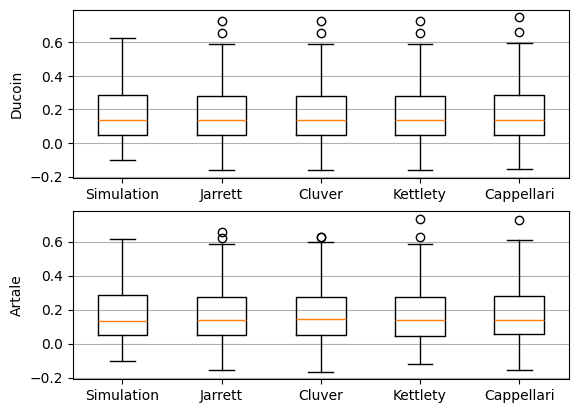

In [15]:
x = [ norm_rank_diff( s_Ducoin_list ),
      norm_rank_diff( s_D_Jarrett_list ),
      norm_rank_diff( s_D_Cluver_list ),
      norm_rank_diff( s_D_Kettlety_list ),
      norm_rank_diff( s_D_Cappellari_list ),
    ]

labels = ['Simulation', 'Jarrett', 'Cluver', 'Kettlety', 'Cappellari' ]

fig, ax = plt.subplots(nrows = 2)
ax[0].set_ylabel('Ducoin')
bplot = ax[0].boxplot( x,  labels=labels )
    
x = [ norm_rank_diff( s_Artale_list ),
      norm_rank_diff( s_A_Jarrett_list ),
      norm_rank_diff( s_A_Cluver_list ),
      norm_rank_diff( s_A_Kettlety_list ),
      norm_rank_diff( s_A_Cappellari_list ),
    ]

ax[1].set_ylabel('Artale')
bplot = ax[1].boxplot( x, labels=labels)  # will be used to label x-ticks

ax[0].yaxis.grid()
ax[1].yaxis.grid()
plt.show()

with violinplots:

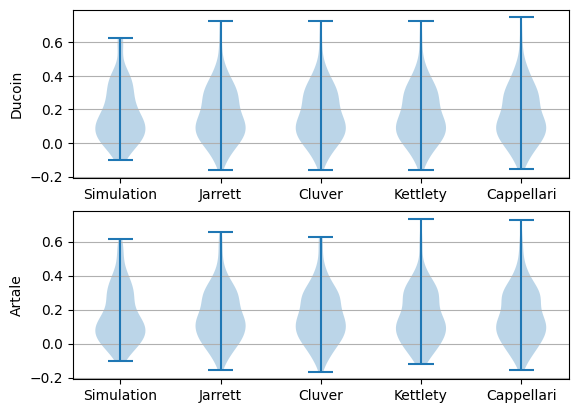

In [16]:
x = [ norm_rank_diff( s_Ducoin_list ),
      norm_rank_diff( s_D_Jarrett_list ),
      norm_rank_diff( s_D_Cluver_list ),
      norm_rank_diff( s_D_Kettlety_list ),
      norm_rank_diff( s_D_Cappellari_list ),
    ]

labels = ['Simulation', 'Jarrett', 'Cluver', 'Kettlety', 'Cappellari' ]

fig, ax = plt.subplots(nrows = 2)
ax[0].set_ylabel('Ducoin')
bplot = ax[0].violinplot( x )
    
x = [ norm_rank_diff( s_Artale_list ),
      norm_rank_diff( s_A_Jarrett_list ),
      norm_rank_diff( s_A_Cluver_list ),
      norm_rank_diff( s_A_Kettlety_list ),
      norm_rank_diff( s_A_Cappellari_list ),
    ]

ax[1].set_ylabel('Artale')
bplot = ax[1].violinplot( x )  # will be used to label x-ticks

ax[0].yaxis.grid()
ax[1].yaxis.grid()
ax[0].set_xticks([y + 1 for y in range(len(x))],
                  labels=labels)
ax[1].set_xticks([y + 1 for y in range(len(x))],
                  labels=labels)
plt.savefig('nrd.png', dpi = 100)
plt.show()

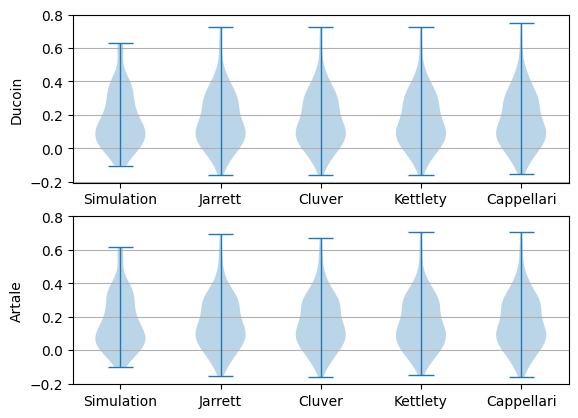

In [17]:
x = [ norm_rank_diff( s_Ducoin_list ),
      norm_rank_diff( s_D_Jarrett_list ),
      norm_rank_diff( s_D_Cluver_list ),
      norm_rank_diff( s_D_Kettlety_list ),
      norm_rank_diff( s_D_Cappellari_list ),
    ]

labels = ['Simulation', 'Jarrett', 'Cluver', 'Kettlety', 'Cappellari' ]

fig, ax = plt.subplots(nrows = 2)
ax[0].set_ylabel('Ducoin')
bplot = ax[0].violinplot( x, showextrema = True )
for partname in ('cbars', 'cmins', 'cmaxes'):
    bplot[partname].set_linewidth(1)  # Adjusts thickness

# Ensure 0.8 is shown in y-axis
yticks = np.arange(-0.2, 1, 0.2)  # Adjust tick spacing as needed
ax[0].set_yticks(yticks)
    
x = [ norm_rank_diff( s_Artalei_list ),
      norm_rank_diff( s_Ai_Jarrett_list ),
      norm_rank_diff( s_Ai_Cluver_list ),
      norm_rank_diff( s_Ai_Kettlety_list ),
      norm_rank_diff( s_Ai_Cappellari_list ),
    ]

ax[1].set_ylabel('Artale')
bplot = ax[1].violinplot( x, showextrema = True )  # will be used to label x-ticks
for partname in ('cbars', 'cmins', 'cmaxes'):
    bplot[partname].set_linewidth(1)  # Adjusts thickness


ax[0].yaxis.grid()
ax[1].yaxis.grid()
ax[1].set_yticks(yticks)
ax[0].set_xticks([y + 1 for y in range(len(x))],
                  labels=labels)
ax[1].set_xticks([y + 1 for y in range(len(x))],
                  labels=labels)
plt.savefig('nrd_interpolated.png', dpi = 100)
plt.show()

### Normalized rank

In [18]:
def rank( listname ):
    return ( np.array(listname) ) / (length )

Boxplot:

/tmp/ipykernel_9958/3785801473.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax[0].boxplot( x,  labels=labels )
/tmp/ipykernel_9958/3785801473.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax[1].boxplot( x, labels=labels)  # will be used to label x-ticks


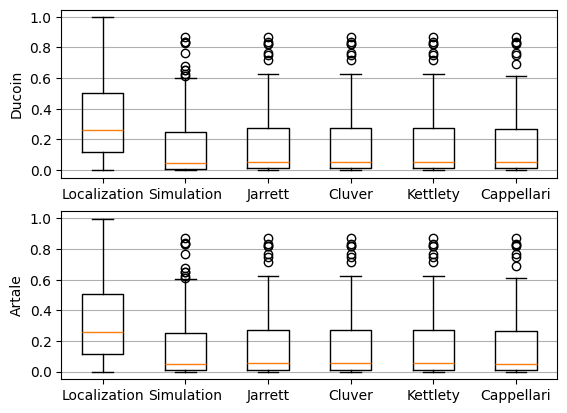

In [19]:
x = [ rank( s_dp_dV_list ),
      rank( s_Ducoin_list ),
      rank( s_D_Jarrett_list ),
      rank( s_D_Cluver_list ),
      rank( s_D_Kettlety_list ),
      rank( s_D_Cappellari_list ),
    ]

labels = ['Localization', 'Simulation', 'Jarrett', 'Cluver', 'Kettlety', 'Cappellari' ]

fig, ax = plt.subplots(nrows = 2)
ax[0].set_ylabel('Ducoin')
bplot = ax[0].boxplot( x,  labels=labels )
    
x = [ rank( s_dp_dV_list ),
      rank( s_Ducoin_list ),
      rank( s_D_Jarrett_list ),
      rank( s_D_Cluver_list ),
      rank( s_D_Kettlety_list ),
      rank( s_D_Cappellari_list ),
    ]

ax[1].set_ylabel('Artale')
bplot = ax[1].boxplot( x, labels=labels)  # will be used to label x-ticks

ax[0].yaxis.grid()
ax[1].yaxis.grid()
plt.show()

Violinplot:

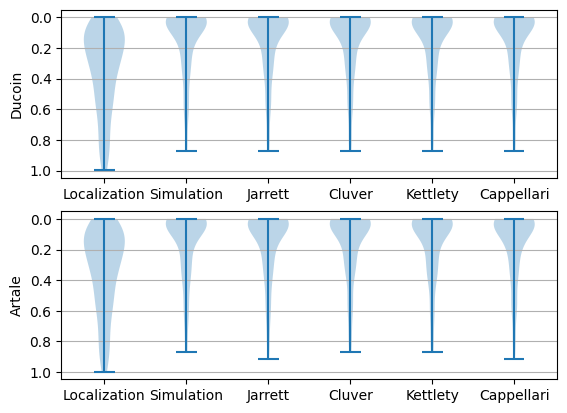

In [20]:
x = [ rank( s_dp_dV_list ),
      rank( s_Ducoin_list ),
      rank( s_D_Jarrett_list ),
      rank( s_D_Cluver_list ),
      rank( s_D_Kettlety_list ),
      rank( s_D_Cappellari_list ),
    ]

labels = ['Localization', 'Simulation', 'Jarrett', 'Cluver', 'Kettlety', 'Cappellari' ]

fig, ax = plt.subplots(nrows = 2)
ax[0].set_ylabel('Ducoin')
bplot = ax[0].violinplot( x )
plt.gca().invert_yaxis()
#ax[0].set_yscale('log')
    
x = [ rank( s_dp_dV_list ),
      rank( s_Artale_list ),
      rank( s_A_Jarrett_list ),
      rank( s_A_Cluver_list ),
      rank( s_A_Kettlety_list ),
      rank( s_A_Cappellari_list ),
    ]

ax[1].set_ylabel('Artale')
bplot = ax[1].violinplot( x )  # will be used to label x-ticks

ax[0].yaxis.grid()
ax[1].yaxis.grid()
ax[0].set_xticks([y + 1 for y in range(len(x))],
                  labels=labels)
ax[1].set_xticks([y + 1 for y in range(len(x))],
                  labels=labels)
ax[0].yaxis.set_inverted(True)
#plt.yscale('log')
plt.savefig('rank.png', dpi = 100)
plt.show()

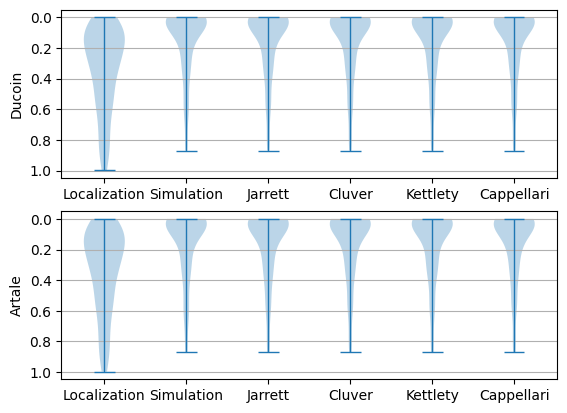

In [21]:
x = [ rank( s_dp_dV_list ),
      rank( s_Ducoin_list ),
      rank( s_D_Jarrett_list ),
      rank( s_D_Cluver_list ),
      rank( s_D_Kettlety_list ),
      rank( s_D_Cappellari_list ),
    ]

labels = ['Localization', 'Simulation', 'Jarrett', 'Cluver', 'Kettlety', 'Cappellari' ]

fig, ax = plt.subplots(nrows = 2)
ax[0].set_ylabel('Ducoin')
bplot = ax[0].violinplot( x, showextrema = True )
for partname in ('cbars', 'cmins', 'cmaxes'):
    bplot[partname].set_linewidth(1)  # Adjusts thickness
plt.gca().invert_yaxis()
#ax[0].set_yscale('log')
    
x = [ rank( s_dp_dV_list ),
      rank( s_Artalei_list ),
      rank( s_Ai_Jarrett_list ),
      rank( s_Ai_Cluver_list ),
      rank( s_Ai_Kettlety_list ),
      rank( s_Ai_Cappellari_list ),
    ]

ax[1].set_ylabel('Artale')
bplot = ax[1].violinplot( x, showextrema = True )  # will be used to label x-ticks
for partname in ('cbars', 'cmins', 'cmaxes'):
    bplot[partname].set_linewidth(1)  # Adjusts thickness

ax[0].yaxis.grid()
ax[1].yaxis.grid()
ax[0].set_xticks([y + 1 for y in range(len(x))],
                  labels=labels)
ax[1].set_xticks([y + 1 for y in range(len(x))],
                  labels=labels)
ax[0].yaxis.set_inverted(True)
#plt.yscale('log')
plt.savefig('rank_interpolated.png', dpi = 100)
plt.show()